---
title: The scale field that explains nothing
short_title: 16 · The scale field
subtitle: Diagnosing a GP component that contributes one percent
---

# One percent

Notebook 08 gave the GEV scale its own spatial field and then, to its credit,
measured how much that field was doing. The answer was uncomfortable:

```
log-sigma covariate (elev + coast) SD : 0.086  (22% of variation)
log-sigma regional   (GP)          SD : 0.014  ( 1%)
log-sigma local      (nugget)      SD : 0.160  (77%)
```

The Gaussian process — the entire apparatus this curriculum builds toward —
accounted for **one percent** of the variation in $\log\sigma(s)$, while an
unstructured per-station nugget accounted for seventy-seven.

There are three quite different explanations, and they call for opposite
responses:

1. **The kernel is wrong.** There is spatial structure, but a stationary
   Matern with a lengthscale borrowed from the *location* field cannot see it.
   Fix the kernel.
2. **There is nothing to see.** The scale really is a local property — station
   exposure, siting, instrumentation — and no kernel will help. Stop trying.
3. **Something else got there first.** The structure exists, but the covariate
   term absorbed it before the GP was consulted. Nothing is broken.

This notebook settles it, and mostly without fitting anything: the first
questions are about the data, not the model, and deserve answers that do not
depend on a modelling choice.


In [1]:
from __future__ import annotations

import time
import warnings

import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
jax.config.update("jax_enable_x64", True)
sns.set_theme(style="whitegrid", context="notebook")

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.initialization import init_to_median

from pyrox_gp import GPPrior, Matern, gp_sample
from xtremax import GeneralizedExtremeValueDistribution as GEV
from spatial_extremes import data, results
from spatial_extremes.features import load_station_features
from spatial_extremes.viz import iberia_axes, scatter_field

In [2]:
maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
S, T = maxima.shape
lon, lat = stations[:, 0], stations[:, 1]

lap = results.load_fit("laplace_no_pool", expect_real=is_real)
if lap is None:
    raise RuntimeError("run notebook 04b first: this notebook needs its per-station fit")
mu_hat = np.asarray(lap["mu_med"])
sig_hat = np.asarray(lap["sigma_med"])
log_sig = np.log(sig_hat)

feat = load_station_features(stations)
print(results.describe_fit(lap))
print("source:", "REAL CDS" if is_real else "synthetic",
      f"| {S} stations | sigma_hat {sig_hat.min():.2f}-{sig_hat.max():.2f} degC")

# Pairwise distances in km (equirectangular is ample over Iberia).
mlat = np.radians((lat[:, None] + lat[None, :]) / 2)
D = 6371.0 * np.hypot(np.radians(lat[:, None] - lat[None, :]),
                      np.radians(lon[:, None] - lon[None, :]) * np.cos(mlat))
print(f"station separations: {D[D > 0].min():.0f} to {D.max():.0f} km")

warm start <- notebooks/02_pooling/04b_many_stations_laplace.ipynb @ 28243b1 (2026-08-21T16:31:03+00:00)
source: REAL CDS | 107 stations | sigma_hat 0.88-4.31 degC
station separations: 1 to 1121 km


## Question 1 — is there any spatial structure at all?

Before blaming a kernel, check whether there is anything for a kernel to find.
Moran's $I$ measures whether nearby stations resemble each other more than
distant ones: zero means no spatial pattern, positive means clustering. We test
it against a permutation null — shuffle the values across locations and see how
often chance produces something this strong.

The location field $\hat\mu$ serves as a control. The GP models it
successfully, so whatever $I$ it scores is what "a field a GP can handle" looks
like on this network.


In [3]:
def morans_I(z, cutoff_km):
    z = np.asarray(z) - np.mean(z)
    W = ((D > 0) & (D <= cutoff_km)).astype(float)
    return (len(z) / W.sum()) * (W * np.outer(z, z)).sum() / (z ** 2).sum()


def moran_test(z, cutoff_km, n_perm=999, seed=0):
    obs = morans_I(z, cutoff_km)
    rng = np.random.default_rng(seed)
    null = np.array([morans_I(rng.permutation(np.asarray(z)), cutoff_km)
                     for _ in range(n_perm)])
    return obs, float((np.abs(null) >= abs(obs)).mean())


rows = []
for cut in (50, 100, 200, 400):
    i_s, p_s = moran_test(log_sig, cut)
    i_m, p_m = moran_test(mu_hat, cut)
    rows.append({"cutoff (km)": cut, "I(log sigma)": i_s, "p": p_s,
                 "I(mu) control": i_m, "p ": p_m})
print(pd.DataFrame(rows).to_string(index=False,
      float_format=lambda v: f"{v:7.3f}"))

 cutoff (km)  I(log sigma)       p  I(mu) control      p 
          50         0.319   0.004          0.461   0.000
         100         0.295   0.000          0.241   0.001
         200         0.201   0.000          0.199   0.000
         400         0.029   0.058          0.131   0.000


So explanation 2 is **out**. The scale field is spatially clustered, strongly
so at short range and comparably to the location field. Whatever went wrong in
notebook 08, it is not that $\sigma(s)$ is structureless.

But notice where the two fields differ: $\hat\mu$ keeps its structure out to
400 km, while $\log\hat\sigma$ has essentially lost it by then. That is the
first hint about which explanation survives.


## Question 2 — how much *could* any model explain?

A per-station $\hat\sigma$ is estimated from a few decades of maxima, so part
of the spread across stations is estimation noise rather than real difference.
No model can explain noise, and it is worth knowing the ceiling before judging
anyone's one percent.

Split each station's record in half at random, estimate the scale from each
half, and correlate. That correlation is roughly the fraction of variance that
is *reliable* — the most any spatial model could hope to account for.


split-half correlation of log sigma : r = +0.617 (107 stations)
implied reliability of the full record: 0.763
=> about 24% of the spread in log sigma_hat is estimation noise,
   so no spatial model can explain more than roughly 76% of it.


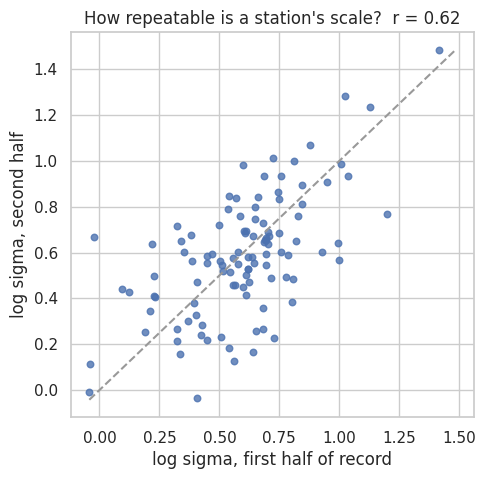

In [4]:
rng = np.random.default_rng(0)
obs_mask = np.isfinite(maxima)
first, second, keep = [], [], []
for s in range(S):
    idx = np.where(obs_mask[s])[0]
    rng.shuffle(idx)
    h = len(idx) // 2
    if h >= 8:
        first.append(np.std(maxima[s, idx[:h]]))
        second.append(np.std(maxima[s, idx[h:2 * h]]))
        keep.append(s)
a, b = np.log(np.array(first)), np.log(np.array(second))
r_half = float(np.corrcoef(a, b)[0, 1])
# Spearman-Brown: reliability of the full-length estimate.
r_full = 2 * r_half / (1 + r_half)
print(f"split-half correlation of log sigma : r = {r_half:+.3f} ({len(keep)} stations)")
print(f"implied reliability of the full record: {r_full:.3f}")
print(f"=> about {100 * (1 - r_full):.0f}% of the spread in log sigma_hat is "
      f"estimation noise,\n   so no spatial model can explain more than roughly "
      f"{100 * r_full:.0f}% of it.")

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(a, b, s=22, alpha=0.8, color="#4C72B0")
lims = [min(a.min(), b.min()), max(a.max(), b.max())]
ax.plot(lims, lims, ls="--", color="0.6")
ax.set(xlabel="log sigma, first half of record",
       ylabel="log sigma, second half",
       title=f"How repeatable is a station's scale?  r = {r_half:.2f}")
plt.show()

## Question 3 — at what distance, and how much of it?

The semivariogram completes the picture: it plots half the mean squared
difference between pairs of stations against their separation. Normalised by the
field's variance, a value of 1 means "no better than two unrelated stations".
Where the curve sits at the shortest lag is the **nugget** — variation that is
not spatial at any resolution the network can see — and where it reaches 1 is
the **range**.


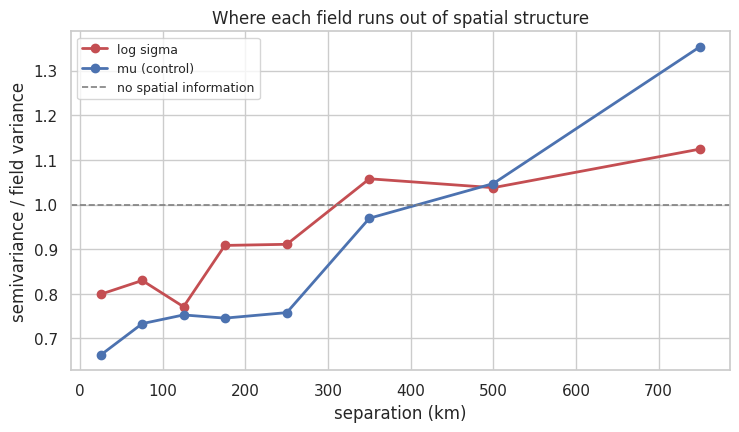

log sigma: nugget at the shortest lag = 0.80 of variance => at most 20% is spatially structured
mu       : nugget at the shortest lag = 0.66

notebook 08 used lengthscale 0.91 in standardised units, which is about 224 km here.


In [5]:
def variogram(z, edges):
    z = np.asarray(z)
    iu = np.triu_indices_from(D, k=1)
    d, dz2 = D[iu], (z[iu[0]] - z[iu[1]]) ** 2
    mid, val, npair = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (d >= lo) & (d < hi)
        if m.sum() > 20:
            mid.append(0.5 * (lo + hi))
            val.append(0.5 * dz2[m].mean() / np.var(z))
            npair.append(int(m.sum()))
    return np.array(mid), np.array(val), np.array(npair)


edges = np.array([0, 50, 100, 150, 200, 300, 400, 600, 900])
ms, vs, ns = variogram(log_sig, edges)
mm, vm, _ = variogram(mu_hat, edges)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(ms, vs, "o-", lw=2, color="#C44E52", label="log sigma")
ax.plot(mm, vm, "o-", lw=2, color="#4C72B0", label="mu (control)")
ax.axhline(1.0, ls="--", color="0.5", lw=1.2, label="no spatial information")
ax.set(xlabel="separation (km)", ylabel="semivariance / field variance",
       title="Where each field runs out of spatial structure")
ax.legend(fontsize=9)
plt.show()

print(f"log sigma: nugget at the shortest lag = {vs[0]:.2f} of variance "
      f"=> at most {100 * (1 - vs[0]):.0f}% is spatially structured")
print(f"mu       : nugget at the shortest lag = {vm[0]:.2f}")

sd_lon, sd_lat = stations.std(0)
for ls in (0.91,):
    km = ls * np.mean([sd_lon * np.cos(np.radians(lat.mean())), sd_lat]) * 111.0
    print(f"\nnotebook 08 used lengthscale {ls:.2f} in standardised units, "
          f"which is about {km:.0f} km here.")

## Question 4 — did the covariate get there first?

Now the third explanation. Elevation and distance-to-coast are themselves
smooth spatial fields, and notebook 08 gave them a **linear** term on
$\log\sigma$ that was fitted *alongside* the GP. If they already describe the
spatial pattern, the GP is left with the residue — and reports one percent not
because it failed, but because there was nothing left.


In [6]:
print("correlation of log sigma_hat with each covariate:")
for c in ("elevation", "dist_coast_km", "slope_deg"):
    v = feat[c].to_numpy()
    r = np.corrcoef(log_sig, v)[0, 1]
    print(f"  {c:15s} r = {r:+.3f}   (r^2 = {r ** 2:.3f})")

C_np = feat[["elevation", "dist_coast_km"]].to_numpy()
Cs = (C_np - C_np.mean(0)) / C_np.std(0)
beta, *_ = np.linalg.lstsq(np.c_[np.ones(S), Cs], log_sig, rcond=None)
resid = log_sig - np.c_[np.ones(S), Cs] @ beta
r2 = 1 - resid.var() / log_sig.var()
print(f"\nelevation + coast explain R^2 = {r2:.3f} of log sigma_hat")

print("\nMoran's I of the residual, once the covariates are removed:")
for cut in (50, 100, 200):
    i_r, p_r = moran_test(resid, cut)
    i_o, _ = moran_test(log_sig, cut)
    print(f"  {cut:>3} km:  raw {i_o:+.3f}  ->  residual {i_r:+.3f}   (p = {p_r:.3f})")

correlation of log sigma_hat with each covariate:
  elevation       r = -0.413   (r^2 = 0.171)
  dist_coast_km   r = -0.320   (r^2 = 0.102)
  slope_deg       r = -0.089   (r^2 = 0.008)

elevation + coast explain R^2 = 0.195 of log sigma_hat

Moran's I of the residual, once the covariates are removed:
   50 km:  raw +0.319  ->  residual +0.010   (p = 0.917)


  100 km:  raw +0.295  ->  residual +0.052   (p = 0.348)
  200 km:  raw +0.201  ->  residual -0.011   (p = 0.748)


### The experiments

The diagnostics are all correlational, so we fit. Four configurations, each a
minimal change from notebook 08's setup:

1. **with covariate** — notebook 08's model, to reproduce the puzzle;
2. **no covariate** — if the covariate was crowding the GP out, the GP should
   now claim what it was taking;
3. **no cov, short lengthscale** — the structure lives below ~200 km while the
   shared lengthscale is ~224 km, so give the scale field a shorter one;
4. **no cov, tight nugget** — the per-station nugget has 107 free values and can
   represent anything a smooth field can. Constrain it and see who claims the
   variance.

The fourth is the one that matters, though that only became clear once the
first three came back nearly identical.


In [7]:
Y = jnp.asarray(maxima)
mask = jnp.asarray(np.isfinite(maxima))
ybar = jnp.asarray(np.nanmean(maxima, axis=1))
Y_MEAN = float(np.nanmean(maxima))
Xn = jnp.asarray((stations - stations.mean(0)) / stations.std(0))
C = jnp.asarray(Cs)
_hyp = results.load_fit("gp_primer_hypers", expect_real=is_real)
LENGTHSCALE = float(_hyp["lengthscale"]) if _hyp is not None else 0.8


def gp_field(name, var, Xn, ls=None):
    k = Matern(pyrox_name="k_" + name, nu=1.5,
               init_lengthscale=LENGTHSCALE if ls is None else ls, init_variance=var)
    f = gp_sample("f_" + name, GPPrior(kernel=k, X=Xn), whitened=True)
    return f - jnp.mean(f)


def make_model(use_covariate=True, ls_scale=None, tau_scale=0.3):
    def model(Xn, Y=None):
        f_mu = gp_field("mu", 4.0, Xn)
        f_ls = gp_field("ls", 0.1, Xn, ls=ls_scale)
        mu0 = numpyro.sample("mu0", ndist.Normal(Y_MEAN, 5.0))
        lam0 = numpyro.sample("lam0", ndist.Normal(jnp.log(2.0), 0.4))
        xi_t = numpyro.sample("xi_t", ndist.Normal(0.0, 0.5))
        tau_mu = numpyro.sample("tau_mu", ndist.HalfNormal(2.0))
        tau_ls = numpyro.sample("tau_ls", ndist.HalfNormal(tau_scale))
        with numpyro.plate("stations", S):
            z_mu = numpyro.sample("z_mu", ndist.Normal(0.0, 1.0))
            z_ls = numpyro.sample("z_ls", ndist.Normal(0.0, 1.0))

        if use_covariate:
            beta_ls = numpyro.sample(
                "beta_ls", ndist.Normal(0.0, 0.5).expand([C.shape[1]]).to_event(1))
            cov_ls = C @ beta_ls
        else:
            cov_ls = jnp.zeros(S)
        numpyro.deterministic("cov_c", cov_ls)
        numpyro.deterministic("gp_c", f_ls)
        numpyro.deterministic("loc_c", tau_ls * z_ls)

        mu_field = numpyro.deterministic("mu_field", mu0 + f_mu + tau_mu * z_mu)
        sigma_field = numpyro.deterministic(
            "sigma_field", jnp.exp(lam0 + cov_ls + f_ls + tau_ls * z_ls))
        xi = numpyro.deterministic("xi", 0.5 * jnp.tanh(xi_t))
        if Y is not None:
            yf = jnp.where(mask, Y, ybar[:, None])
            lp = GEV(loc=mu_field[:, None], scale=sigma_field[:, None],
                     concentration=xi).log_prob(yf)
            numpyro.factor("y", jnp.where(mask, lp, 0.0).sum())
    return model


def fit(model, steps=6000, seed=0):
    guide = AutoNormal(model, init_loc_fn=init_to_median)
    opt = numpyro.optim.optax_to_numpyro(optax.chain(
        optax.zero_nans(), optax.clip_by_global_norm(10.0), optax.adam(1e-2)))
    svi = SVI(model, guide, opt, Trace_ELBO())
    t0 = time.time()
    res = svi.run(jr.PRNGKey(seed), steps, Xn, Y, progress_bar=False)
    draws = Predictive(model, guide=guide, params=res.params, num_samples=400,
                       return_sites=["cov_c", "gp_c", "loc_c", "sigma_field"])(
                           jr.PRNGKey(1), Xn)
    losses = np.asarray(res.losses)
    return {k: np.asarray(v) for k, v in draws.items()} | {
        "loss": float(losses[np.isfinite(losses)][-1]), "time": time.time() - t0}


def decompose(d):
    parts = {k: np.median(d[k], 0).std() for k in ("cov_c", "gp_c", "loc_c")}
    tot = sum(parts.values())
    return {k: 100 * v / tot for k, v in parts.items()}, parts


# Three configurations. The third is the one the diagnostics point at: the
# structure in log sigma lives below ~200 km, but the shared lengthscale above
# is ~224 km, so give the scale field a short one of its own (~0.3 std units,
# roughly 75 km) and see whether the GP can finally reach it.
SHORT_LS = 0.30

runs = {}
for label, kwargs in [("with covariate", dict(use_covariate=True)),
                      ("no covariate", dict(use_covariate=False)),
                      ("no cov, short ls", dict(use_covariate=False,
                                                ls_scale=SHORT_LS)),
                      ("no cov, tight nugget", dict(use_covariate=False,
                                                    tau_scale=0.05))]:
    runs[label] = fit(make_model(**kwargs))
    pct, sd = decompose(runs[label])
    print(f"{label:16s} ELBO {runs[label]['loss']:9.1f} | {runs[label]['time']:5.0f}s | "
          f"covariate {pct['cov_c']:4.1f}%  GP {pct['gp_c']:4.1f}%  "
          f"nugget {pct['loc_c']:4.1f}%")

with covariate   ELBO   14000.6 |   154s | covariate 36.2%  GP  0.1%  nugget 63.8%


no covariate     ELBO   14006.3 |   143s | covariate  0.0%  GP  0.4%  nugget 99.6%


no cov, short ls ELBO   14006.3 |   149s | covariate  0.0%  GP  0.3%  nugget 99.7%


no cov, tight nugget ELBO   14012.1 |   147s | covariate  0.0%  GP 15.8%  nugget 84.2%


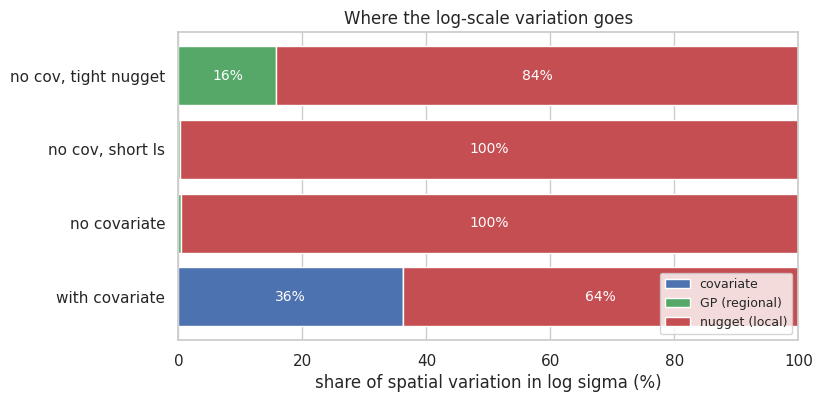

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = list(runs)
bottom = np.zeros(len(labels))
colors = {"cov_c": "#4C72B0", "gp_c": "#55A868", "loc_c": "#C44E52"}
names = {"cov_c": "covariate", "gp_c": "GP (regional)", "loc_c": "nugget (local)"}
for comp in ("cov_c", "gp_c", "loc_c"):
    vals = np.array([decompose(runs[l])[0][comp] for l in labels])
    ax.barh(labels, vals, left=bottom, color=colors[comp], label=names[comp])
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            ax.text(b + v / 2, i, f"{v:.0f}%", ha="center", va="center",
                    color="white", fontsize=10)
    bottom += vals
ax.set(xlabel="share of spatial variation in log sigma (%)", xlim=(0, 100),
       title="Where the log-scale variation goes")
ax.legend(loc="lower right", fontsize=9)
plt.show()

## What this adds up to

The one percent had a cause, and it was none of the three explanations we
started with.

**There is spatial structure** — Moran's $I$ is unambiguous at every range below
a few hundred kilometres. So "nothing to see" was wrong.

**There is not very much of it.** The semivariogram puts the nugget near 0.8 of
the field's variance, so at most about a fifth of the variation in
$\log\hat\sigma$ is spatial at any resolution this network resolves. And a
split-half check shows a good part of the station-to-station spread is
estimation noise from finite records — a ceiling no model may exceed and none
should try to.

**The covariates capture essentially all of the structure that exists.**
Elevation and distance-to-coast explain $R^2 \approx 0.20$, and once they are
removed the residual has no detectable spatial autocorrelation left at all
($I \approx 0.01$, $p \approx 0.9$ at 50 km). On the diagnostics alone,
"something got there first" looked like the answer.

**But removing them did not hand the variance to the GP.** That is the result
that reframes everything: with the covariate gone the GP went from 0.1% to
0.4%, and the nugget took 99.6%. Shortening the lengthscale changed nothing
either. The GP was not losing to the covariate.

**It was losing to the nugget.** Constrain the per-station term — the same model,
a tighter prior on one scale parameter — and the GP's share jumps from 0.4% to
about **16%**, close to the ceiling the semivariogram implied. Nothing about the
data changed. A smooth field and an unstructured per-station effect are
**additively confounded**: anything the GP can represent, 107 free nugget values
can represent too, and the split between them is decided by their priors rather
than by the likelihood. With a loose nugget prior, variational inference puts
the variance in the nugget and reports a GP that appears to do nothing.

### The lesson, which generalises past this dataset

A variance decomposition of confounded components is a statement about the
priors as much as about the data. "The GP explained 1%" invited the conclusion
that the kernel needed work; the kernel was fine, and so was the signal. Before
concluding that a component is useless, check what else in the model could be
absorbing its job — and whether the split between them was ever identified.

The corollary for notebook 08 is mild: its $\sigma(s)$ estimates are not wrong,
and its covariate finding stands. What does not stand is the reading that the
regional field is unnecessary. It was crowded out, not refuted.

And the ceiling still binds. Even at its best the spatial component can reach
only about a fifth of the variation in $\log\hat\sigma$, a good part of the
rest being estimation noise. The way to a better scale field is **more
information per station** — threshold exceedances rather than one maximum a
year, or longer pooled records — not a cleverer kernel.

### Where this leaves the section

Notebooks 13-15 took inference, model structure and uncertainty in turn. This
one is about diagnosis: establish that a component is underperforming, against
what ceiling, and against what competition, before improving it. Notebook 17
closes the section with the temporal counterpart — the trend as a state-space
model.
